In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    cohen_kappa_score
)



In [6]:
import seaborn as sns

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [3]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [9]:
metadata_path = "../data/metadata/unified_metadata.csv"

df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (42541, 44)


C:\Users\aditi\AppData\Local\Temp\ipykernel_39064\3894872885.py:3: DtypeWarning: Columns (4,27,28,29,30,38,39,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_path)


,dataset,image_key,image_id,source_split,official_split,image_path,extension,label_dr,has_label,label_source,...,processed_format,preprocess_status,dataset_source,dme_label,dme_label_source,dme_label_scheme,lesion_available,lesion_annotation_type,patient_id,patient_id_status
0,aptos,aptos__8a58801bb4e89fda,000c1434d8d7,train,NaN,data/raw/aptos/train_images/000c1434d8d7.png,.png,2.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
1,aptos,aptos__c8827d05711175da,001639a390f0,train,NaN,data/raw/aptos/train_images/001639a390f0.png,.png,4.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
2,aptos,aptos__2b8228ecc008b575,0024cdab0c1e,train,NaN,data/raw/aptos/train_images/0024cdab0c1e.png,.png,1.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
3,aptos,aptos__f9409e06017fe46c,002c21358ce6,train,NaN,data/raw/aptos/train_images/002c21358ce6.png,.png,0.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files
4,aptos,aptos__11b2efaae2c39263,005b95c28852,train,NaN,data/raw/aptos/train_images/005b95c28852.png,.png,0.0,True,aptos/train.csv,...,JPEG,already_exists,aptos,NaN,NaN,NaN,False,NaN,NaN,not available in current source files


In [10]:
important_columns = [
    "dataset",
    "image_path",
    "processed_path",
    "label_dr_standard",
    "dr_grade_name",
    "eligible_for_model",
    "model_split"
]

for col in important_columns:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(20))
    else:
        print(f"\nWARNING: Column '{col}' not found")


dataset:
dataset
eyepacs      35126
aptos         5590
messidor2     1744
idrid           81
Name: count, dtype: int64

image_path:
image_path
data/raw/messidor2/preprocess/IM004832.JPG      1
data/raw/aptos/train_images/000c1434d8d7.png    1
data/raw/aptos/train_images/001639a390f0.png    1
data/raw/aptos/train_images/0024cdab0c1e.png    1
data/raw/aptos/train_images/002c21358ce6.png    1
data/raw/aptos/train_images/005b95c28852.png    1
data/raw/aptos/train_images/0083ee8054ee.png    1
data/raw/aptos/train_images/0097f532ac9f.png    1
data/raw/aptos/train_images/00a8624548a9.png    1
data/raw/aptos/train_images/00b74780d31d.png    1
data/raw/aptos/train_images/00cb6555d108.png    1
data/raw/aptos/train_images/00cc2b75cddd.png    1
data/raw/aptos/train_images/00e4ddff966a.png    1
data/raw/messidor2/preprocess/IM004528.JPG      1
data/raw/messidor2/preprocess/IM004529.JPG      1
data/raw/messidor2/preprocess/IM004537.JPG      1
data/raw/messidor2/preprocess/IM004538.JPG      1
data/r

In [11]:
model_df = df[
    df["eligible_for_model"] == True
].copy()

print("Total images:", len(df))
print("Eligible images:", len(model_df))
print("Excluded images:", len(df) - len(model_df))

Total images: 42541
Eligible images: 40613
Excluded images: 1928


In [12]:
print(model_df["model_split"].value_counts(dropna=False))

model_split
train         32530
validation     8056
test             27
Name: count, dtype: int64


In [13]:
model_df["model_split"] = (
    model_df["model_split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

model_df["model_split"] = model_df["model_split"].replace({
    "validation": "val",
    "valid": "val"
})

print(model_df["model_split"].value_counts())

model_split
train    32530
val       8056
test        27
Name: count, dtype: int64


In [14]:
train_df = model_df[
    model_df["model_split"] == "train"
].copy()

val_df = model_df[
    model_df["model_split"] == "val"
].copy()

test_df = model_df[
    model_df["model_split"] == "test"
].copy()

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 32530
Validation images: 8056
Test images: 27


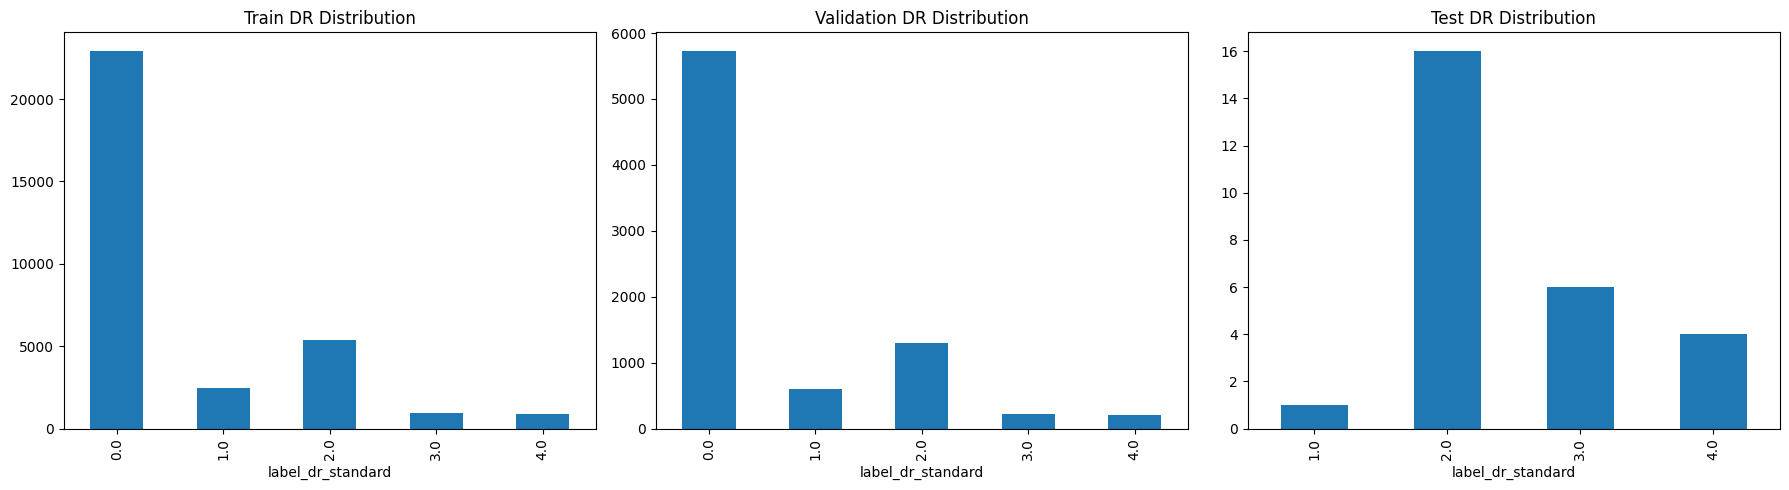

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_df["label_dr_standard"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    title="Train DR Distribution"
)

val_df["label_dr_standard"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    title="Validation DR Distribution"
)

test_df["label_dr_standard"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[2],
    title="Test DR Distribution"
)

plt.tight_layout()
plt.show()

In [16]:
for name, split_df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():
    
    print(f"\n{name} Dataset Distribution:")
    print(split_df["dataset"].value_counts())


Train Dataset Distribution:
dataset
eyepacs      28100
aptos         2978
messidor2     1398
idrid           54
Name: count, dtype: int64

Validation Dataset Distribution:
dataset
eyepacs      7026
aptos         684
messidor2     346
Name: count, dtype: int64

Test Dataset Distribution:
dataset
idrid    27
Name: count, dtype: int64


In [17]:
print("Image path examples:")
print(model_df["image_path"].head())

print("\nProcessed path examples:")
print(model_df["processed_path"].head())

Image path examples:
0    data/raw/aptos/train_images/000c1434d8d7.png
1    data/raw/aptos/train_images/001639a390f0.png
2    data/raw/aptos/train_images/0024cdab0c1e.png
3    data/raw/aptos/train_images/002c21358ce6.png
4    data/raw/aptos/train_images/005b95c28852.png
Name: image_path, dtype: object

Processed path examples:
0    data/processed/images/aptos/aptos__8a58801bb4e...
1    data/processed/images/aptos/aptos__c8827d05711...
2    data/processed/images/aptos/aptos__2b8228ecc00...
3    data/processed/images/aptos/aptos__f9409e06017...
4    data/processed/images/aptos/aptos__11b2efaae2c...
Name: processed_path, dtype: object


In [24]:
sample_paths = model_df["processed_path"].dropna().head(10)

for path in sample_paths:
    print(path, "->", os.path.exists(path))

data/processed/images/aptos/aptos__8a58801bb4e89fda.jpg -> False
data/processed/images/aptos/aptos__c8827d05711175da.jpg -> False
data/processed/images/aptos/aptos__2b8228ecc008b575.jpg -> False
data/processed/images/aptos/aptos__f9409e06017fe46c.jpg -> False
data/processed/images/aptos/aptos__11b2efaae2c39263.jpg -> False
data/processed/images/aptos/aptos__2a1c2e5e9b4f774b.jpg -> False
data/processed/images/aptos/aptos__9b0b1f3110f4a445.jpg -> False
data/processed/images/aptos/aptos__56f97594ad38fa59.jpg -> False
data/processed/images/aptos/aptos__73fd205e1180581e.jpg -> False
data/processed/images/aptos/aptos__2bc5841cf5eee5f8.jpg -> False


In [19]:
print("Current working directory:")
print(os.getcwd())

print("\nFirst 10 processed paths:")
print(model_df["processed_path"].dropna().head(10).to_list())

print("\nFirst 10 original image paths:")
print(model_df["image_path"].dropna().head(10).to_list())

Current working directory:
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\notebooks

First 10 processed paths:
['data/processed/images/aptos/aptos__8a58801bb4e89fda.jpg', 'data/processed/images/aptos/aptos__c8827d05711175da.jpg', 'data/processed/images/aptos/aptos__2b8228ecc008b575.jpg', 'data/processed/images/aptos/aptos__f9409e06017fe46c.jpg', 'data/processed/images/aptos/aptos__11b2efaae2c39263.jpg', 'data/processed/images/aptos/aptos__2a1c2e5e9b4f774b.jpg', 'data/processed/images/aptos/aptos__9b0b1f3110f4a445.jpg', 'data/processed/images/aptos/aptos__56f97594ad38fa59.jpg', 'data/processed/images/aptos/aptos__73fd205e1180581e.jpg', 'data/processed/images/aptos/aptos__2bc5841cf5eee5f8.jpg']

First 10 original image paths:
['data/raw/aptos/train_images/000c1434d8d7.png', 'data/raw/aptos/train_images/001639a390f0.png', 'data/raw/aptos/train_images/0024cdab0c1e.png', 'data/raw/aptos/train_images/002c21358ce6.png', 'data/raw/aptos/train_images/005b95c28852.png', 'data/r

In [21]:
from pathlib import Path

# Current notebook is inside the notebooks folder
PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed images folder exists:")
print((PROJECT_ROOT / "data" / "processed" / "images").exists())

Project root:
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project

Processed images folder exists:
False


In [20]:
print(os.listdir(".."))

['.git', '.gitignore', 'data', 'docs', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'venv']


In [23]:
print("Raw data folder exists:")
print((PROJECT_ROOT / "data" / "raw").exists())

print("\nAPTOS folder exists:")
print((PROJECT_ROOT / "data" / "raw" / "aptos").exists())

print("\nContents of data folder:")
print(os.listdir(PROJECT_ROOT / "data"))

Raw data folder exists:
False

APTOS folder exists:
False

Contents of data folder:
['metadata', 'processed']


In [25]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

print("\nData folder contents:")
print(os.listdir(PROJECT_ROOT / "data"))

print("\nProcessed folder contents:")
print(os.listdir(PROJECT_ROOT / "data" / "processed"))

Project root: c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project

Data folder contents:
['metadata', 'processed']

Processed folder contents:
['images', 'metadata']


In [26]:
processed_root = PROJECT_ROOT / "data" / "processed"

for root, dirs, files in os.walk(processed_root):
    print(root, "->", len(files), "files")

c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed -> 0 files
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed\images -> 0 files
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed\images\aptos -> 5590 files
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed\images\eyepacs -> 35126 files
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed\images\idrid -> 81 files
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed\images\messidor2 -> 1744 files
c:\Users\aditi\Desktop\DR\Diabetic-Retinopathy-Screening-Project\data\processed\metadata -> 0 files


In [27]:
processed_root = PROJECT_ROOT / "data" / "processed" / "images"

print("Processed root exists:", processed_root.exists())

Processed root exists: True


In [28]:
def fix_path(path):
    
    if pd.isna(path):
        return None
    
    path = str(path).replace("\\", "/")
    
    full_path = PROJECT_ROOT / path
    
    return str(full_path)


model_df["final_image_path"] = model_df["processed_path"].apply(fix_path)

model_df["path_exists"] = model_df["final_image_path"].apply(
    lambda x: os.path.exists(x)
)

print("Images with valid paths:", model_df["path_exists"].sum())
print("Images without valid paths:", (~model_df["path_exists"]).sum())

Images with valid paths: 40613
Images without valid paths: 0


In [29]:
model_df = model_df[model_df["path_exists"]].copy()

train_df = model_df[model_df["model_split"] == "train"].copy()
val_df = model_df[model_df["model_split"] == "val"].copy()
test_df = model_df[model_df["model_split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 32530
Validation: 8056
Test: 27


In [30]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [31]:
from torch.utils.data import Dataset
from PIL import Image

class DRDataset(Dataset):
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        
        row = self.dataframe.iloc[index]

        image_path = row["final_image_path"]
        label = int(row["label_dr_standard"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [32]:
train_dataset = DRDataset(
    train_df,
    transform=train_transform
)

val_dataset = DRDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = DRDataset(
    test_df,
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 32530
Validation: 8056
Test: 27


In [33]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 2


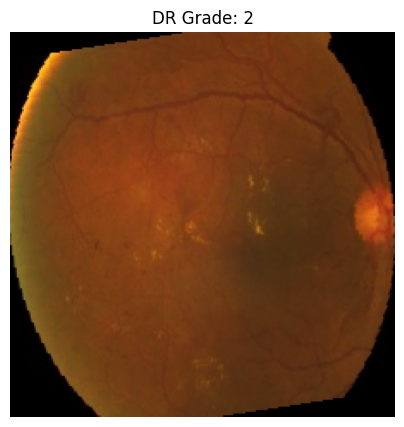

In [34]:
image, label = train_dataset[0]

image_np = image.permute(1, 2, 0).numpy()

# Undo normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = image_np * std + mean
image_np = np.clip(image_np, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.title(f"DR Grade: {label}")
plt.axis("off")
plt.show()

In [35]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# Use 0 on Windows to avoid multiprocessing issues
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [36]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels:", labels)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels: tensor([2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
        0, 0, 0, 0, 1, 2, 0, 0])


Class counts:
label_dr_standard
0.0    22908
1.0     2479
2.0     5356
3.0      932
4.0      855
Name: count, dtype: int64


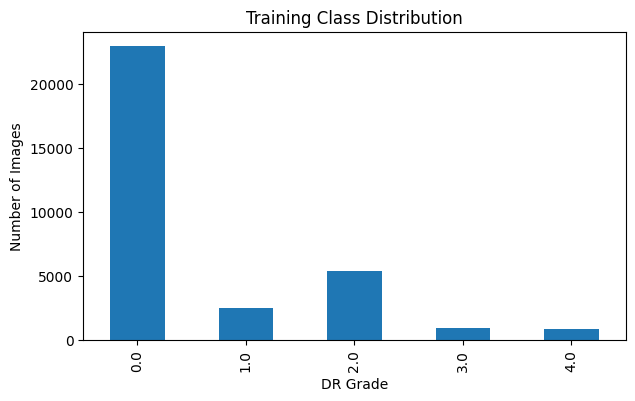

In [37]:
class_counts = (
    train_df["label_dr_standard"]
    .value_counts()
    .sort_index()
)

print("Class counts:")
print(class_counts)

plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")

plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("Training Class Distribution")

plt.show()

In [38]:
class_counts = class_counts.reindex([0, 1, 2, 3, 4], fill_value=1)

class_weights = len(train_df) / (
    5 * class_counts
)

print("Class weights:")
print(class_weights)

Class weights:
label_dr_standard
0    0.284006
1    2.624445
2    1.214712
3    6.980687
4    7.609357
Name: count, dtype: float64


In [39]:
class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
).to(device)

print(class_weights_tensor)

tensor([0.2840, 2.6244, 1.2147, 6.9807, 7.6094])


In [40]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    5
)

model = model.to(device)

print("Model loaded successfully")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\aditi/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:22<00:00, 2.07MB/s]


Model loaded successfully
Device: cpu


In [41]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [42]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return epoch_loss, epoch_accuracy

In [43]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probabilities)
    )

In [44]:
os.makedirs("../results", exist_ok=True)

print("Results folder ready")

Results folder ready


In [45]:
EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_accuracy,
        val_labels,
        val_predictions,
        val_probabilities
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../results/best_resnet18_baseline.pth"
        )

        print("✓ Best model saved")


Epoch 1/10


KeyboardInterrupt: 